# TripBranch 취향 RAG 검색 평가 — 폐쇄형 테스트셋 v1

용산·성동의 **네이버 블로그 근거문장 v3 + Google 리뷰**로 네 가지 검색 조합을 비교합니다.

이 노트북의 목표는 단순히 점수 하나를 뽑는 것이 아닙니다.

1. 같은 문서가 구조적 청킹과 시멘틱 청킹에서 어떻게 달라지는지 직접 확인합니다.
2. 취향별 Top 5 장소와 실제 근거 청크를 네 조합에서 나란히 비교합니다.
3. `Precision@5`, `nDCG@5`, 구축 시간, 검색 시간을 차트로 비교합니다.
4. 발표 자료에 캡처하기 쉽도록 결과 화면의 색·순서·레이아웃을 고정합니다.

> **실행 전:** Colab 메뉴에서 `런타임 → 런타임 유형 변경 → T4 GPU`를 선택하세요. CPU에서도 실행은 가능하지만 Qwen3와 리랭커가 매우 느립니다.

## 목차

1. 실험 설계 확인
2. 패키지 설치와 실행 환경
3. 평가 파일 연결
4. 입력 검증과 평가셋 분포
5. 120토큰 청킹 함수
6. 구조적·시멘틱 청크 생성
7. 실제 청크 원문 비교
8. 임베딩·BM25 구축
9. 네 가지 검색 조합 실행
10. Precision@5·nDCG@5 평가
11. 품질·구축·검색 시간 시각화
12. 취향별 Top 5 결과 카드
13. 결과 파일 저장과 다운로드

## 1. 실험 설계 확인

검색 대상은 모든 조합에서 동일한 **55개 장소, 1,500개 후기 문서**입니다. 특정 질의의 정답 장소만 따로 검색하지 않습니다.

| ID | 모델 | 청킹 | 검색 |
|---|---|---|---|
| A | jhgan/ko-sroberta-multitask | 구조적 120토큰 | Dense |
| B | jhgan/ko-sroberta-multitask | 시멘틱 120토큰 | Dense |
| C | jhgan/ko-sroberta-multitask | 구조적 120토큰 | Dense + BM25 + Reranker |
| D | Qwen3-Embedding-0.6B | 구조적 120토큰 | Dense |

### 점수 해석

- **Precision@5:** 상위 5곳 중 1점 이상 정답이 차지하는 비율입니다. 높을수록 엉뚱한 장소가 적습니다.
- **nDCG@5:** 2점짜리 강한 정답을 1점짜리 보조 정답보다 위에 배치했는지 봅니다.
- **구축 시간:** 모델 다운로드를 제외한 청킹·임베딩·BM25 준비 시간입니다.
- **검색 시간:** 모델을 이미 메모리에 올린 운영 상태에서 질문 하나를 처리한 평균 시간입니다.

`Recall`은 취향마다 정답 수가 다르고 후보 풀이 표본이므로 핵심 지표에서 제외합니다.

## 2. 패키지 설치와 실행 환경

Colab 기본 pandas와 PyTorch를 강제로 업그레이드하지 않습니다. 이전에 발생한 `tokenizers` 소스 빌드와 `setuptools` 충돌을 피하기 위해 바이너리 wheel을 우선 사용합니다.

설치 후 별도 오류가 없다면 런타임을 다시 시작하지 않고 다음 셀로 진행해도 됩니다.

In [ ]:
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

FONT_PATH = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
assert FONT_PATH.exists(), f"한글 폰트를 찾지 못했습니다: {FONT_PATH}"

fm.fontManager.addfont(str(FONT_PATH))
FONT_NAME = fm.FontProperties(fname=str(FONT_PATH)).get_name()

plt.rcParams["font.family"] = FONT_NAME
plt.rcParams["axes.unicode_minus"] = False

print("적용된 한글 폰트:", FONT_NAME)

적용된 한글 폰트: NanumGothic


In [ ]:
%pip -q install --only-binary=tokenizers \
  "tokenizers>=0.21,<1" \
  "transformers>=4.51,<5" \
  "sentence-transformers>=5,<6" \
  "kiwipiepy>=0.21" \
  "rank-bm25==0.2.2"

!apt-get -qq install -y fonts-nanum > /dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import gc, hashlib, html, json, math, re, shutil, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display
from kiwipiepy import Kiwi
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder, SentenceTransformer
from transformers import AutoTokenizer
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
kiwi = Kiwi()
print("실행 장치:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음 — T4 GPU 권장")

실행 장치: cuda
GPU: Tesla T4


## 3. 평가 파일 연결

평가 폴더를 Google Drive에 올린 뒤 `DRIVE_EVAL_DIR`만 실제 경로로 바꾸세요. 폴더 안에는 아래 네 파일이 있어야 합니다.

- `evaluation_queries.csv`
- `evaluation_candidate_places.csv`
- `evaluation_qrels.csv`
- `evaluation_corpus.csv`

Drive를 쓰지 않으려면 `USE_GOOGLE_DRIVE=False`로 바꾸고 네 CSV를 한꺼번에 업로드합니다.

In [ ]:
USE_GOOGLE_DRIVE = True
DRIVE_EVAL_DIR = "/content/drive/MyDrive/TripBranch_RAG_Distributed_Embedding/preference_retrieval_closed_pool_v2"  # 실제 경로로 수정

REQUIRED_FILES = [
    "evaluation_queries.csv",
    "evaluation_candidate_places.csv",
    "evaluation_qrels.csv",
    "evaluation_corpus.csv",
]

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path(DRIVE_EVAL_DIR)
else:
    from google.colab import files
    uploaded = files.upload()
    DATA_DIR = Path("/content/preference_eval_inputs")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for name, payload in uploaded.items():
        (DATA_DIR / name).write_bytes(payload)

missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"필수 파일이 없습니다: {missing}\n확인 경로: {DATA_DIR}")

OUTPUT_DIR = Path("/content/tripbranch_preference_eval_v1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("입력 폴더:", DATA_DIR)
print("결과 폴더:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
입력 폴더: /content/drive/MyDrive/TripBranch_RAG_Distributed_Embedding/preference_retrieval_closed_pool_v2
결과 폴더: /content/tripbranch_preference_eval_v1


## 4. 입력 검증과 평가셋 분포

여기서는 실험 전에 다음을 확인합니다.

- 검색 후보가 55곳인지
- 각 장소가 8개 취향에 모두 판정됐는지
- 최종 점수가 0·1·2 중 하나인지
- 검색 코퍼스가 네이버·Google만 포함하는지

아래 누적 막대그래프는 취향별 난도를 보여줍니다. 0점 장소가 적을수록 Precision@5가 쉽게 높아질 수 있다는 점을 함께 봐야 합니다.

In [ ]:
queries = pd.read_csv(DATA_DIR / "evaluation_queries.csv", dtype=str, keep_default_na=False)
candidates = pd.read_csv(DATA_DIR / "evaluation_candidate_places.csv", dtype=str, keep_default_na=False)
qrels = pd.read_csv(DATA_DIR / "evaluation_qrels.csv", dtype=str, keep_default_na=False)
docs = pd.read_csv(DATA_DIR / "evaluation_corpus.csv", dtype=str, keep_default_na=False)

for frame in (queries, candidates, qrels, docs):
    if "content_id" in frame.columns:
        frame["content_id"] = frame["content_id"].astype(str)

qrels["relevance_grade_final"] = pd.to_numeric(qrels["relevance_grade_final"], errors="raise").astype(int)
queries["query_variant"] = pd.to_numeric(queries["query_variant"], errors="raise").astype(int)
docs["embedding_text"] = docs["embedding_text"].str.replace(r"\\n", "\n", regex=True)

assert candidates.content_id.nunique() == 55, "후보 장소 수가 55곳이 아닙니다."
assert queries.preference_code.nunique() == 8 and len(queries) == 16
assert len(qrels) == 55 * 8
assert set(qrels.relevance_grade_final.unique()) <= {0, 1, 2}
assert set(docs.source_type.unique()) <= {"naver_post", "google_review"}
assert set(docs.content_id).issubset(set(candidates.content_id))
assert qrels.groupby("content_id").preference_code.nunique().eq(8).all()

print(f"장소 {candidates.content_id.nunique():,}곳 · 질의 {len(queries):,}개 · 정답 판정 {len(qrels):,}개")
print(f"검색 문서 {len(docs):,}건 · 네이버 {docs.source_type.eq('naver_post').sum():,} · Google {docs.source_type.eq('google_review').sum():,}")
display(queries[["case_id", "preference_label", "query_variant", "query"]])

장소 55곳 · 질의 16개 · 정답 판정 440개
검색 문서 1,500건 · 네이버 1,080 · Google 420


,case_id,preference_label,query_variant,query
0,photo_spot_q1,사진 명소,1,사진 찍기 좋은 장소
1,photo_spot_q2,사진 명소,2,인생 사진을 남기기 좋은 곳
2,healing_q1,힐링하기 좋은,1,편안하게 쉬며 힐링하기 좋은 장소
3,healing_q2,힐링하기 좋은,2,여유롭게 머리를 식힐 수 있는 곳
4,unique_q1,색다른 경험,1,색다른 경험을 할 수 있는 장소
5,unique_q2,색다른 경험,2,평범하지 않은 이색적인 곳
6,quiet_q1,조용한 곳,1,조용히 쉬기 좋은 장소
7,quiet_q2,조용한 곳,2,사람이 붐비지 않고 차분한 곳
8,spacious_q1,넓고 쾌적한,1,넓고 쾌적하게 머물 수 있는 장소
9,spacious_q2,넓고 쾌적한,2,공간이 넓고 답답하지 않은 곳


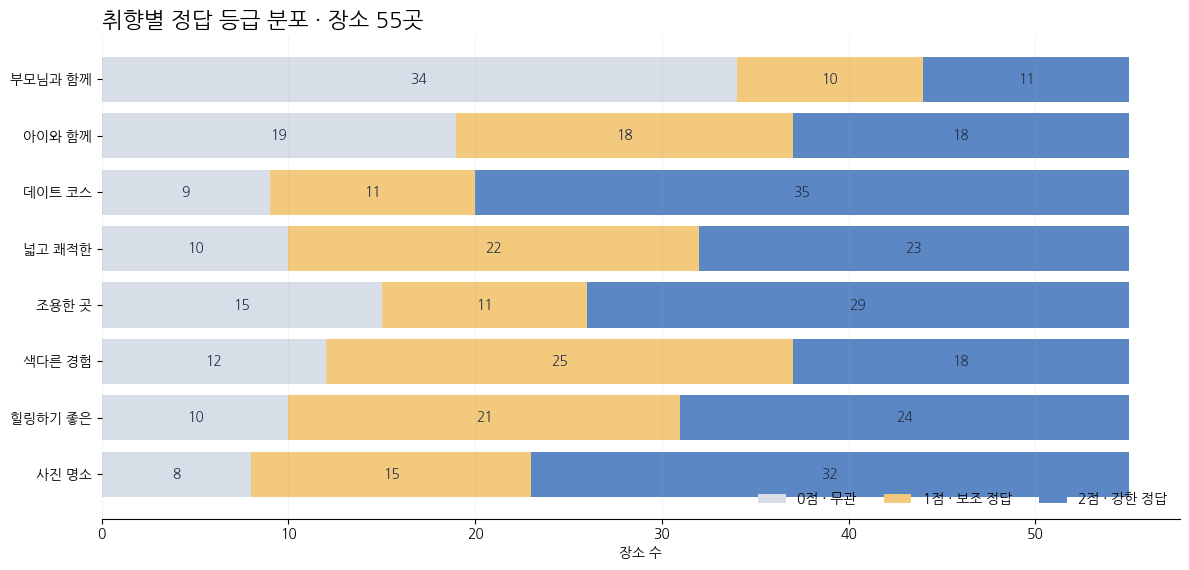

In [ ]:
grade_counts = (
    qrels.groupby(["preference_label", "relevance_grade_final"]).size()
    .unstack(fill_value=0).reindex(columns=[0, 1, 2], fill_value=0)
)
preference_order = queries.drop_duplicates("preference_code").preference_label.tolist()
grade_counts = grade_counts.reindex(preference_order)

colors = {0: "#D7DEE8", 1: "#F2C97D", 2: "#5C87C5"}
fig, ax = plt.subplots(figsize=(12, 5.8))
left = np.zeros(len(grade_counts))
for grade, label in [(0, "0점 · 무관"), (1, "1점 · 보조 정답"), (2, "2점 · 강한 정답")]:
    values = grade_counts[grade].to_numpy()
    bars = ax.barh(grade_counts.index, values, left=left, label=label, color=colors[grade])
    for bar, value in zip(bars, values):
        if value:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    str(int(value)), ha="center", va="center", fontsize=10, color="#263247")
    left += values
ax.set_title("취향별 정답 등급 분포 · 장소 55곳", loc="left", fontsize=16, fontweight="bold")
ax.set_xlabel("장소 수")
ax.legend(ncol=3, frameon=False, loc="lower right")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qrels_grade_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. 120토큰 청킹 함수

두 방법 모두 **동일한 토크나이저와 최대 120토큰**을 사용합니다. 차이는 어디에서 먼저 끊을지입니다.

- **구조적 청킹:** 문장 순서를 유지하며 다음 문장을 더해도 120토큰 이하면 계속 채웁니다.
- **시멘틱 청킹:** 인접 문장의 의미 유사도가 낮아지는 지점에서 먼저 끊되, 어떤 청크도 120토큰을 넘지 않습니다.

문장 하나 자체가 120토큰을 넘는 예외에만 절 경계(쉼표·세미콜론 등)를 먼저 시도하고, 그래도 길면 토큰 경계로 분할합니다. 이는 모델의 128토큰 한도에서 뒤쪽 문장이 조용히 잘리는 것을 막기 위한 안전장치입니다.

In [ ]:
MAX_TOKENS = 120
MIN_SEMANTIC_TOKENS = 45
SEMANTIC_THRESHOLD = 0.42
CHUNK_TOKENIZER_NAME = "jhgan/ko-sroberta-multitask"

chunk_tokenizer = AutoTokenizer.from_pretrained(CHUNK_TOKENIZER_NAME)

def norm(text):
    return str(text or "").replace("\r\n", "\n").replace("\r", "\n").strip()

def token_ids(text):
    return chunk_tokenizer.encode(str(text), add_special_tokens=False)

def token_len(text):
    return len(token_ids(text))

def raw_sentences(text):
    text = norm(text)
    try:
        found = [item.text.strip() for item in kiwi.split_into_sents(text) if item.text.strip()]
        if found:
            return found
    except Exception:
        pass
    return [x.strip() for x in re.split(r"(?<=[.!?…。！？])\s+|\n+", text) if x.strip()]

def split_oversize_sentence(sentence, limit=MAX_TOKENS):
    if token_len(sentence) <= limit:
        return [sentence]
    clauses = [x.strip() for x in re.split(r"(?<=[,;:，；：·–—])\s*", sentence) if x.strip()]
    if len(clauses) > 1 and all(token_len(x) <= limit for x in clauses):
        return clauses
    ids = token_ids(sentence)
    return [
        chunk_tokenizer.decode(ids[start:start+limit], skip_special_tokens=True).strip()
        for start in range(0, len(ids), limit)
        if ids[start:start+limit]
    ]

def sentence_units(text):
    units = []
    for sentence in raw_sentences(text):
        units.extend(split_oversize_sentence(sentence))
    return [x for x in units if x]

def pack_to_limit(units, limit=MAX_TOKENS):
    chunks, current = [], []
    for unit in units:
        proposed = " ".join(current + [unit]).strip()
        if current and token_len(proposed) > limit:
            chunks.append(" ".join(current).strip())
            current = [unit]
        else:
            current.append(unit)
    if current:
        chunks.append(" ".join(current).strip())
    assert all(token_len(x) <= limit for x in chunks)
    return chunks

def rows_from_pieces(frame, method, pieces_by_doc):
    rows = []
    for row in frame.to_dict("records"):
        pieces = pieces_by_doc.get(row["document_id"], [])
        for index, body in enumerate(pieces):
            rows.append({
                **row,
                "chunking": method,
                "chunk_index": index,
                "chunk_count": len(pieces),
                "chunk_body": body,
                "token_count": token_len(body),
                "char_count": len(body),
                "chunk_id": hashlib.sha256(
                    f"{method}|{row['document_id']}|{index}|{body}".encode("utf-8")
                ).hexdigest()[:24],
            })
    return pd.DataFrame(rows)

tokenizer_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

## 6. 구조적·시멘틱 청크 생성

먼저 구조적 청크를 빠르게 만듭니다. 이어서 jhgan 모델로 인접 문장을 벡터화해 시멘틱 경계를 계산합니다.

시멘틱 청킹 시간에는 **경계 판정을 위한 문장 임베딩 시간까지 포함**됩니다. 따라서 뒤의 구축 시간 비교에서 시멘틱 방식의 추가 비용이 빠지지 않습니다.

In [ ]:
structural_started = time.perf_counter()
structural_pieces = {
    row.document_id: pack_to_limit(sentence_units(row.embedding_text))
    for row in tqdm(docs.itertuples(), total=len(docs), desc="구조적 청킹")
}
structural_chunks = rows_from_pieces(docs, "structural", structural_pieces)
structural_chunking_seconds = time.perf_counter() - structural_started

print(f"구조적 청킹: {len(structural_chunks):,}개 · {structural_chunking_seconds:,.1f}초")
print("최대 토큰:", structural_chunks.token_count.max())

구조적 청킹:   0%|          | 0/1500 [00:00<?, ?it/s]

구조적 청킹: 4,141개 · 28.3초
최대 토큰: 120


In [ ]:
JHGAN_MODEL = "jhgan/ko-sroberta-multitask"
QWEN_MODEL = "Qwen/Qwen3-Embedding-0.6B"
RERANKER_MODEL = "BAAI/bge-reranker-v2-m3"

jhgan_load_started = time.perf_counter()
jhgan_model = SentenceTransformer(JHGAN_MODEL, device=DEVICE)
jhgan_load_seconds = time.perf_counter() - jhgan_load_started

semantic_started = time.perf_counter()
units_by_doc = {row.document_id: sentence_units(row.embedding_text) for row in docs.itertuples()}
unit_rows = [
    (document_id, index, text)
    for document_id, units in units_by_doc.items()
    for index, text in enumerate(units)
]

unit_vectors = jhgan_model.encode(
    [row[2] for row in unit_rows], batch_size=64,
    normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True,
)
vectors_by_doc = {}
for (document_id, index, _), vector in zip(unit_rows, unit_vectors):
    vectors_by_doc.setdefault(document_id, {})[index] = vector

semantic_pieces = {}
for row in tqdm(docs.itertuples(), total=len(docs), desc="시멘틱 경계 조립"):
    units = units_by_doc[row.document_id]
    vectors = vectors_by_doc.get(row.document_id, {})
    pieces, current = [], []
    for index, unit in enumerate(units):
        proposed = " ".join(current + [unit]).strip()
        too_long = bool(current) and token_len(proposed) > MAX_TOKENS
        current_tokens = token_len(" ".join(current)) if current else 0
        similarity = None if index == 0 else float(np.dot(vectors[index-1], vectors[index]))
        topic_change = (
            similarity is not None
            and similarity < SEMANTIC_THRESHOLD
            and current_tokens >= MIN_SEMANTIC_TOKENS
        )
        if current and (too_long or topic_change):
            pieces.append(" ".join(current).strip())
            current = []
        current.append(unit)
    if current:
        pieces.append(" ".join(current).strip())
    semantic_pieces[row.document_id] = pieces

semantic_chunks = rows_from_pieces(docs, "semantic", semantic_pieces)
semantic_chunking_seconds = time.perf_counter() - semantic_started

del unit_vectors, vectors_by_doc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"시멘틱 청킹: {len(semantic_chunks):,}개 · {semantic_chunking_seconds:,.1f}초")
print("최대 토큰:", semantic_chunks.token_count.max())

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

시멘틱 경계 조립:   0%|          | 0/1500 [00:00<?, ?it/s]

시멘틱 청킹: 5,704개 · 52.1초
최대 토큰: 120


In [ ]:
chunk_stats = pd.DataFrame([
    {
        "청킹 방식": "구조적 120토큰",
        "전체 청크": len(structural_chunks),
        "청크 중앙 토큰": int(structural_chunks.token_count.median()),
        "청크 중앙 글자": int(structural_chunks.char_count.median()),
        "문서당 청크 중앙값": float(structural_chunks.groupby("document_id").size().median()),
        "청킹 시간(초)": round(structural_chunking_seconds, 1),
    },
    {
        "청킹 방식": "시멘틱 120토큰",
        "전체 청크": len(semantic_chunks),
        "청크 중앙 토큰": int(semantic_chunks.token_count.median()),
        "청크 중앙 글자": int(semantic_chunks.char_count.median()),
        "문서당 청크 중앙값": float(semantic_chunks.groupby("document_id").size().median()),
        "청킹 시간(초)": round(semantic_chunking_seconds, 1),
    },
])
display(chunk_stats.style.hide(axis="index").format({"청킹 시간(초)": "{:.1f}"}))

청킹 방식,전체 청크,청크 중앙 토큰,청크 중앙 글자,문서당 청크 중앙값,청킹 시간(초)
구조적 120토큰,4141,100,193,3.000000,28.3
시멘틱 120토큰,5704,61,119,4.000000,52.1


## 7. 실제 청크 원문 비교

아래 출력은 같은 문서의 구조적 청크와 시멘틱 청크를 좌우로 보여줍니다.

- 청크 전문을 생략하지 않습니다.
- 각 박스 상단에서 청크 번호·토큰 수·글자 수를 확인합니다.
- 시멘틱 청크가 너무 짧게 잘렸거나 서로 다른 주제가 한 청크에 섞였는지 눈으로 봅니다.

발표 캡처에는 문서 하나만 남기고 나머지 출력은 접어도 됩니다.

In [ ]:
def chunk_html(frame, document_id, accent):
    part = frame[frame.document_id.eq(document_id)].sort_values("chunk_index")
    return "".join(
        f'''<div class="chunk-box" style="border-left:5px solid {accent}">
          <div class="chunk-meta">청크 {int(r.chunk_index)+1}/{int(r.chunk_count)} · {int(r.token_count)}토큰 · {int(r.char_count)}자</div>
          <div class="chunk-text">{html.escape(str(r.chunk_body))}</div>
        </div>'''
        for r in part.itertuples()
    ) or "<p>청크 없음</p>"

def show_chunk_comparison(document_id):
    raw = docs[docs.document_id.eq(document_id)].iloc[0]
    display(HTML(f'''<style>
      .chunk-report{{font-family:Arial,sans-serif;color:#263247;margin:22px 0}}
      .chunk-head{{border-bottom:2px solid #263247;padding-bottom:8px}}
      .chunk-grid{{display:grid;grid-template-columns:1fr 1fr;gap:18px;align-items:start}}
      .chunk-column{{background:#F8FAFC;border-radius:12px;padding:13px}}
      .chunk-box{{background:white;border-radius:8px;padding:11px;margin:9px 0;box-shadow:0 1px 2px #00000012}}
      .chunk-meta{{font-size:12px;font-weight:700;color:#52627A;margin-bottom:6px}}
      .chunk-text{{font-size:13px;line-height:1.68;white-space:pre-wrap;overflow-wrap:anywhere}}
      @media(max-width:900px){{.chunk-grid{{grid-template-columns:1fr}}}}
    </style><section class="chunk-report">
      <div class="chunk-head"><h2>{html.escape(str(raw.place_title))}</h2>
      <div>{html.escape(str(raw.post_title or raw.source_type))} · {html.escape(str(raw.source_type))}</div></div>
      <div class="chunk-grid">
        <div class="chunk-column"><h3>구조적 120토큰</h3>{chunk_html(structural_chunks, document_id, '#5C87C5')}</div>
        <div class="chunk-column"><h3>시멘틱 120토큰</h3>{chunk_html(semantic_chunks, document_id, '#8E6CBE')}</div>
      </div></section>'''))

sample_ids = []
for source_type in ["naver_post", "google_review"]:
    subset = structural_chunks[structural_chunks.source_type.eq(source_type)]
    if len(subset):
        doc_id = (
            subset.groupby("document_id").chunk_count.max().sort_values(ascending=False).index[0]
        )
        sample_ids.append(doc_id)

for document_id in sample_ids:
    show_chunk_comparison(document_id)

## 8. 임베딩과 BM25 구축

같은 청크를 여러 번 임베딩하지 않도록 필요한 세 조합만 계산합니다.

1. jhgan × 구조적 청크
2. jhgan × 시멘틱 청크
3. Qwen3 × 구조적 청크

하이브리드 조합에 필요한 BM25 인덱스는 구조적 청크에 한 번만 만듭니다. Qwen3는 모델 권장 방식에 따라 **질의에만 검색 지시문**을 적용하고 문서 청크에는 붙이지 않습니다.

In [ ]:
QUERY_TEXTS = queries["query"].tolist()

def encode_documents(model, texts, batch_size=64):
    return model.encode(
        texts, batch_size=batch_size, normalize_embeddings=True,
        show_progress_bar=True, convert_to_numpy=True,
    ).astype("float32")

def encode_single_query(model, text, qwen=False):
    kwargs = dict(normalize_embeddings=True, show_progress_bar=False, convert_to_numpy=True)
    if qwen:
        try:
            vector = model.encode([text], prompt_name="query", **kwargs)
        except Exception:
            instructed = "Instruct: Retrieve Korean place reviews relevant to the travel preference.\nQuery: " + text
            vector = model.encode([instructed], **kwargs)
    else:
        vector = model.encode([text], **kwargs)
    return vector[0].astype("float32")

jh_struct_started = time.perf_counter()
jh_struct_vectors = encode_documents(jhgan_model, structural_chunks.chunk_body.tolist())
jh_struct_embedding_seconds = time.perf_counter() - jh_struct_started

jh_sem_started = time.perf_counter()
jh_semantic_vectors = encode_documents(jhgan_model, semantic_chunks.chunk_body.tolist())
jh_semantic_embedding_seconds = time.perf_counter() - jh_sem_started
_ = encode_single_query(jhgan_model, QUERY_TEXTS[0])  # 최초 호출 준비 시간은 검색 지연에서 제외
jh_query_vectors, jh_query_seconds = [], []
for text in QUERY_TEXTS:
    started = time.perf_counter()
    jh_query_vectors.append(encode_single_query(jhgan_model, text))
    jh_query_seconds.append(time.perf_counter() - started)
jh_query_vectors = np.vstack(jh_query_vectors)

del jhgan_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"jhgan × 구조적: {jh_struct_embedding_seconds:,.1f}초")
print(f"jhgan × 시멘틱: {jh_semantic_embedding_seconds:,.1f}초")

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

Batches:   0%|          | 0/90 [00:00<?, ?it/s]

jhgan × 구조적: 21.7초
jhgan × 시멘틱: 23.7초


In [ ]:
qwen_load_started = time.perf_counter()
qwen_kwargs = {"device": DEVICE, "trust_remote_code": True}
if torch.cuda.is_available():
    qwen_kwargs["model_kwargs"] = {"torch_dtype": torch.float16}
qwen_model = SentenceTransformer(QWEN_MODEL, **qwen_kwargs)
qwen_load_seconds = time.perf_counter() - qwen_load_started

qwen_struct_started = time.perf_counter()
qwen_struct_vectors = encode_documents(qwen_model, structural_chunks.chunk_body.tolist(), batch_size=32)
qwen_struct_embedding_seconds = time.perf_counter() - qwen_struct_started

_ = encode_single_query(qwen_model, QUERY_TEXTS[0], qwen=True)
qwen_query_vectors, qwen_query_seconds = [], []
for text in QUERY_TEXTS:
    started = time.perf_counter()
    qwen_query_vectors.append(encode_single_query(qwen_model, text, qwen=True))
    qwen_query_seconds.append(time.perf_counter() - started)
qwen_query_vectors = np.vstack(qwen_query_vectors)
del qwen_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Qwen3 × 구조적: {qwen_struct_embedding_seconds:,.1f}초")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

Batches:   0%|          | 0/130 [00:00<?, ?it/s]

Qwen3 × 구조적: 55.6초


In [ ]:
def bm25_terms(text):
    terms = [
        token.form.lower() for token in kiwi.tokenize(str(text))
        if len(token.form) >= 2 and (
            token.tag.startswith(("N", "V", "M", "XR")) or token.form.isalnum()
        )
    ]
    return terms or [str(text).lower()]

bm25_started = time.perf_counter()
bm25_tokens = [bm25_terms(text) for text in tqdm(structural_chunks.chunk_body, desc="BM25 토큰화")]
bm25_index = BM25Okapi(bm25_tokens)
bm25_build_seconds = time.perf_counter() - bm25_started
print(f"BM25 준비: {bm25_build_seconds:,.1f}초")

BM25 토큰화:   0%|          | 0/4141 [00:00<?, ?it/s]

BM25 준비: 17.7초


## 9. 네 가지 검색 조합 실행

검색은 청크에서 시작하지만 최종 결과는 **장소 단위**로 합칩니다. 한 블로그의 여러 청크가 상위 순위를 독점하지 않도록 같은 장소·문서의 최고 청크만 먼저 남깁니다.

장소 점수는 최고 근거를 중심으로 두 번째·세 번째 독립 문서 근거를 작게 보너스로 반영합니다.

```text
장소 점수 = 1위 근거 × 1.00 + 2위 근거 × 0.15 + 3위 근거 × 0.10
```

하이브리드 조합은 Dense와 BM25 순위를 RRF로 합친 뒤 상위 청크만 리랭커가 다시 읽습니다. 검색 시간에는 질의 임베딩과 실제 검색·리랭킹이 포함되며 모델 최초 다운로드 시간은 제외합니다.

In [ ]:
COMBOS = [
    {"id":"A", "label":"jhgan · 구조적 · Dense", "color":"#4C78A8"},
    {"id":"B", "label":"jhgan · 시멘틱 · Dense", "color":"#8E6CBE"},
    {"id":"C", "label":"jhgan · 구조적 · Hybrid+Reranker", "color":"#4FA3A5"},
    {"id":"D", "label":"Qwen3 · 구조적 · Dense", "color":"#F2A65A"},
]
COMBO_BY_ID = {item["id"]: item for item in COMBOS}
RRF_K = 60
RERANK_CANDIDATE_CHUNKS = 50
TOP_N = 5

def rank_positions(scores):
    order = np.argsort(-scores)
    ranks = np.empty(len(scores), dtype=np.int32)
    ranks[order] = np.arange(1, len(scores) + 1)
    return ranks

def aggregate_places(frame, scores, top_n=TOP_N):
    work = frame.copy()
    work["retrieval_score"] = np.asarray(scores, dtype=float)
    work = work.sort_values("retrieval_score", ascending=False)
    work = work.drop_duplicates(["content_id", "document_id"])
    work["evidence_rank"] = work.groupby("content_id").cumcount() + 1
    evidence = work[work.evidence_rank.le(3)].copy()

    place_rows = []
    for (content_id, place_title, district_code), group in evidence.groupby(
        ["content_id", "place_title", "district_code"], sort=False
    ):
        ordered = group.sort_values("retrieval_score", ascending=False)
        values = ordered.retrieval_score.head(3).tolist()
        weights = [1.0, 0.15, 0.10]
        place_score = sum(value * weights[i] for i, value in enumerate(values))
        best = ordered.iloc[0]
        place_rows.append({
            "content_id": str(content_id), "place_title": place_title,
            "district_code": district_code, "place_score": place_score,
            "source_type": best.source_type, "source_url": best.source_url,
            "document_id": best.document_id, "chunk_id": best.chunk_id,
            "chunk_body": best.chunk_body,
        })
    result = pd.DataFrame(place_rows).sort_values("place_score", ascending=False).head(top_n)
    result = result.reset_index(drop=True)
    result["rank"] = np.arange(1, len(result) + 1)
    return result

# 리랭커는 온라인 검색 단계에만 사용합니다.
reranker_load_started = time.perf_counter()
reranker = CrossEncoder(RERANKER_MODEL, device=DEVICE, max_length=512, trust_remote_code=True)
reranker_load_seconds = time.perf_counter() - reranker_load_started
_ = reranker.predict([["테스트 질문", "테스트 근거"]], show_progress_bar=False)
print(f"리랭커 로딩 완료: {reranker_load_seconds:,.1f}초")

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

리랭커 로딩 완료: 24.3초


In [ ]:
result_rows, timing_rows = [], []

for query_index, case in tqdm(list(queries.iterrows()), desc="16개 질의 × 4개 조합"):
    query_text = case["query"]

    # A · jhgan + 구조적 + Dense
    started = time.perf_counter()
    dense_scores = jh_struct_vectors @ jh_query_vectors[query_index]
    ranked = aggregate_places(structural_chunks, dense_scores)
    elapsed = time.perf_counter() - started + jh_query_seconds[query_index]
    for row in ranked.to_dict("records"):
        result_rows.append({**row, **case.to_dict(), "combo_id":"A"})
    timing_rows.append({"case_id":case.case_id, "combo_id":"A", "search_seconds":elapsed})

    # B · jhgan + 시멘틱 + Dense
    started = time.perf_counter()
    dense_scores_sem = jh_semantic_vectors @ jh_query_vectors[query_index]
    ranked = aggregate_places(semantic_chunks, dense_scores_sem)
    elapsed = time.perf_counter() - started + jh_query_seconds[query_index]
    for row in ranked.to_dict("records"):
        result_rows.append({**row, **case.to_dict(), "combo_id":"B"})
    timing_rows.append({"case_id":case.case_id, "combo_id":"B", "search_seconds":elapsed})

    # C · jhgan + 구조적 + Dense/BM25 RRF + Reranker
    started = time.perf_counter()
    dense_scores = jh_struct_vectors @ jh_query_vectors[query_index]
    lexical_scores = np.asarray(bm25_index.get_scores(bm25_terms(query_text)))
    rrf_scores = 1/(RRF_K + rank_positions(dense_scores)) + 1/(RRF_K + rank_positions(lexical_scores))
    candidate_idx = np.argsort(-rrf_scores)[:RERANK_CANDIDATE_CHUNKS]
    candidate_frame = structural_chunks.iloc[candidate_idx].reset_index(drop=True)
    rerank_scores = np.asarray(reranker.predict(
        [[query_text, text] for text in candidate_frame.chunk_body],
        batch_size=32, show_progress_bar=False,
    )).reshape(-1)
    ranked = aggregate_places(candidate_frame, rerank_scores)
    elapsed = time.perf_counter() - started + jh_query_seconds[query_index]
    for row in ranked.to_dict("records"):
        result_rows.append({**row, **case.to_dict(), "combo_id":"C"})
    timing_rows.append({"case_id":case.case_id, "combo_id":"C", "search_seconds":elapsed})

    # D · Qwen3 + 구조적 + Dense
    started = time.perf_counter()
    qwen_scores = qwen_struct_vectors @ qwen_query_vectors[query_index]
    ranked = aggregate_places(structural_chunks, qwen_scores)
    elapsed = time.perf_counter() - started + qwen_query_seconds[query_index]
    for row in ranked.to_dict("records"):
        result_rows.append({**row, **case.to_dict(), "combo_id":"D"})
    timing_rows.append({"case_id":case.case_id, "combo_id":"D", "search_seconds":elapsed})

rankings = pd.DataFrame(result_rows)
search_timing = pd.DataFrame(timing_rows)
print(f"Top 5 결과 행: {len(rankings):,}")
display(search_timing.groupby("combo_id").search_seconds.agg(["mean", "median", "max"]))

16개 질의 × 4개 조합:   0%|          | 0/16 [00:00<?, ?it/s]

Top 5 결과 행: 320


,mean,median,max
combo_id,,,
A,0.062611,0.053346,0.118608
B,0.059204,0.051689,0.103007
C,1.209812,1.216751,1.415100
D,0.097511,0.087342,0.128083


## 10. Precision@5·nDCG@5 평가

각 검색 결과를 해당 취향의 55개 장소 정답표와 비교합니다.

- 1점과 2점은 모두 Precision의 정답입니다.
- nDCG는 2점에 더 큰 이득을 부여하므로 강한 근거가 상단에 나올수록 높아집니다.
- 참고용 `Strict Precision@5`는 2점 장소만 정답으로 계산합니다.

점수가 비슷하면 전체 평균만 보지 말고 아래 취향별 표와 실제 근거 카드를 함께 확인하세요.

In [ ]:
def dcg(grades):
    return sum((2**grade - 1) / math.log2(index + 2) for index, grade in enumerate(grades))

truth_by_preference = {
    preference_code: dict(zip(group.content_id.astype(str), group.relevance_grade_final.astype(int)))
    for preference_code, group in qrels.groupby("preference_code")
}

metric_rows = []
for (combo_id, case_id), frame in rankings.groupby(["combo_id", "case_id"]):
    case = queries[queries.case_id.eq(case_id)].iloc[0]
    truth = truth_by_preference[case.preference_code]
    ordered = frame.sort_values("rank").head(5)
    grades = [truth.get(str(content_id), 0) for content_id in ordered.content_id]
    ideal = sorted(truth.values(), reverse=True)[:5]
    metric_rows.append({
        "combo_id": combo_id,
        "case_id": case_id,
        "preference_code": case.preference_code,
        "preference_label": case.preference_label,
        "query": case["query"],
        "precision_at_5": sum(grade >= 1 for grade in grades) / 5,
        "strict_precision_at_5": sum(grade == 2 for grade in grades) / 5,
        "ndcg_at_5": dcg(grades) / dcg(ideal) if dcg(ideal) else 0.0,
        "retrieved_grades": json.dumps(grades),
    })

metrics_by_query = pd.DataFrame(metric_rows)
metrics_summary = (
    metrics_by_query.groupby("combo_id", as_index=False)
    [["precision_at_5", "strict_precision_at_5", "ndcg_at_5"]].mean()
)
metrics_summary["조합"] = metrics_summary.combo_id.map(
    {item["id"]: item["label"] for item in COMBOS}
)
metrics_summary = metrics_summary.sort_values("ndcg_at_5", ascending=False)
display(
    metrics_summary[["combo_id", "조합", "precision_at_5", "strict_precision_at_5", "ndcg_at_5"]]
    .style.hide(axis="index")
    .format({"precision_at_5":"{:.3f}", "strict_precision_at_5":"{:.3f}", "ndcg_at_5":"{:.3f}"})
    .background_gradient(subset=["precision_at_5", "ndcg_at_5"], cmap="Blues")
)

combo_id,조합,precision_at_5,strict_precision_at_5,ndcg_at_5
A,jhgan · 구조적 · Dense,0.950,0.838,0.893
B,jhgan · 시멘틱 · Dense,0.925,0.838,0.877
C,jhgan · 구조적 · Hybrid+Reranker,0.950,0.812,0.864
D,Qwen3 · 구조적 · Dense,0.887,0.738,0.794


## 11. 품질·구축·검색 시간 시각화

첫 번째 차트는 품질, 두 번째 차트는 운영 비용을 분리해 보여줍니다. 단위가 다른 구축 초와 검색 밀리초를 한 축에 섞지 않습니다.

발표 시에는 다음 순서로 읽으면 됩니다.

1. Precision@5가 충분히 높은가?
2. 그중 nDCG@5가 높은 조합은 무엇인가?
3. 품질 차이가 작다면 구축 시간과 검색 시간을 감수할 가치가 있는가?

모든 막대에 실제 수치를 직접 표시하여 범례만 보고 추측하지 않게 했습니다.

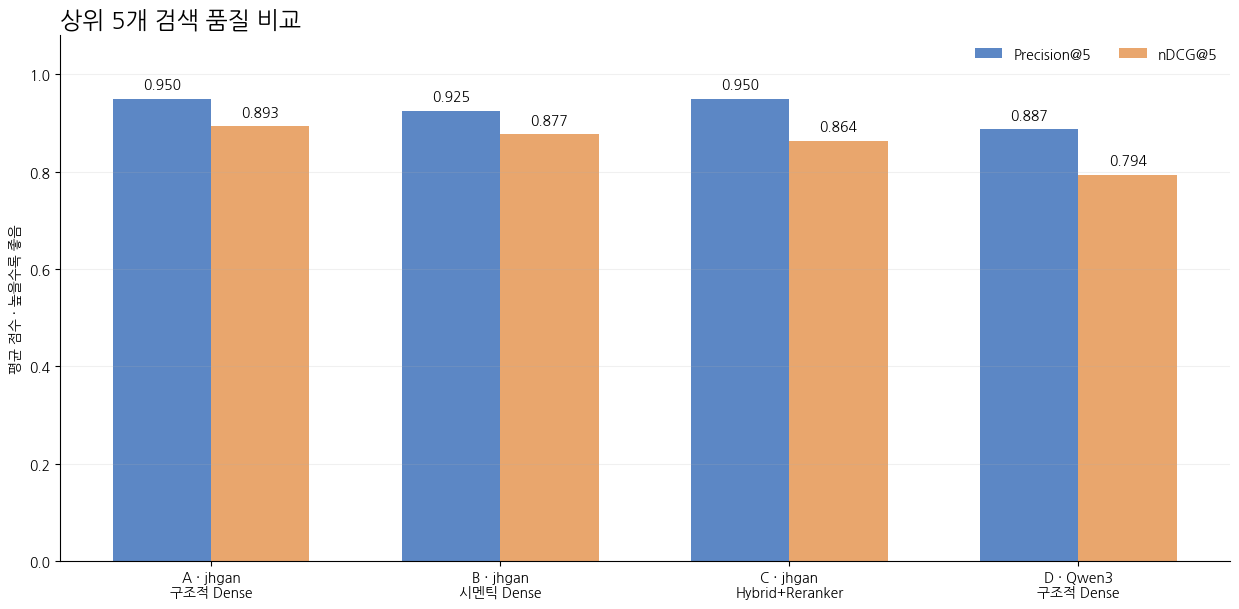

In [ ]:
build_rows = [
    {"combo_id":"A", "build_seconds":structural_chunking_seconds + jh_struct_embedding_seconds},
    {"combo_id":"B", "build_seconds":semantic_chunking_seconds + jh_semantic_embedding_seconds},
    {"combo_id":"C", "build_seconds":structural_chunking_seconds + jh_struct_embedding_seconds + bm25_build_seconds},
    {"combo_id":"D", "build_seconds":structural_chunking_seconds + qwen_struct_embedding_seconds},
]
build_timing = pd.DataFrame(build_rows)
avg_search = search_timing.groupby("combo_id", as_index=False).search_seconds.mean()
avg_search["search_ms_per_query"] = avg_search.search_seconds * 1000

metrics_summary = (
    metrics_summary.merge(build_timing, on="combo_id")
    .merge(avg_search[["combo_id", "search_ms_per_query"]], on="combo_id")
)

order = [item["id"] for item in COMBOS]
summary_plot = metrics_summary.set_index("combo_id").reindex(order).reset_index()
short_labels = {
    "A":"A · jhgan\n구조적 Dense",
    "B":"B · jhgan\n시멘틱 Dense",
    "C":"C · jhgan\nHybrid+Reranker",
    "D":"D · Qwen3\n구조적 Dense",
}
combo_colors = {item["id"]:item["color"] for item in COMBOS}

fig, ax = plt.subplots(figsize=(12.5, 6.2))
x = np.arange(len(summary_plot)); width = 0.34
bars1 = ax.bar(x-width/2, summary_plot.precision_at_5, width, label="Precision@5", color="#5C87C5")
bars2 = ax.bar(x+width/2, summary_plot.ndcg_at_5, width, label="nDCG@5", color="#E9A66D")
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.015, f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x, [short_labels[c] for c in summary_plot.combo_id])
ax.set_ylim(0, 1.08)
ax.set_ylabel("평균 점수 · 높을수록 좋음")
ax.set_title("상위 5개 검색 품질 비교", loc="left", fontsize=17, fontweight="bold")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quality_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

AttributeError: 'DataFrame' object has no attribute 'build_seconds'

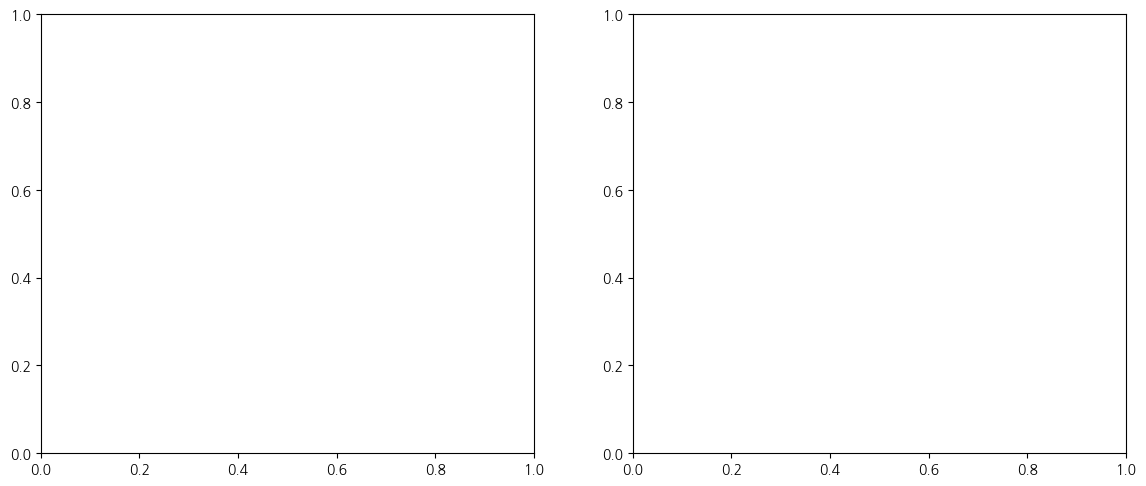

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.7))
colors = [combo_colors[c] for c in summary_plot.combo_id]

bars = axes[0].bar([short_labels[c] for c in summary_plot.combo_id], summary_plot.build_seconds, color=colors)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f"{bar.get_height():,.1f}초", ha="center", fontweight="bold")
axes[0].set_title("코퍼스 구축 시간", loc="left", fontsize=15, fontweight="bold")
axes[0].set_ylabel("초 · 모델 다운로드 제외")

bars = axes[1].bar([short_labels[c] for c in summary_plot.combo_id], summary_plot.search_ms_per_query, color=colors)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f"{bar.get_height():,.0f}ms", ha="center", fontweight="bold")
axes[1].set_title("질문 1개당 평균 검색 시간", loc="left", fontsize=15, fontweight="bold")
axes[1].set_ylabel("밀리초 · 모델 로딩 제외")

for ax in axes:
    ax.grid(axis="y", alpha=.16)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)
plt.suptitle("품질이 비슷하다면 구축·응답 비용까지 함께 비교", x=.06, ha="left", fontsize=17, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "runtime_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    summary_plot[["combo_id", "조합", "precision_at_5", "ndcg_at_5", "build_seconds", "search_ms_per_query"]]
    .style.hide(axis="index")
    .format({
        "precision_at_5":"{:.3f}", "ndcg_at_5":"{:.3f}",
        "build_seconds":"{:,.1f}초", "search_ms_per_query":"{:,.0f}ms",
    })
)

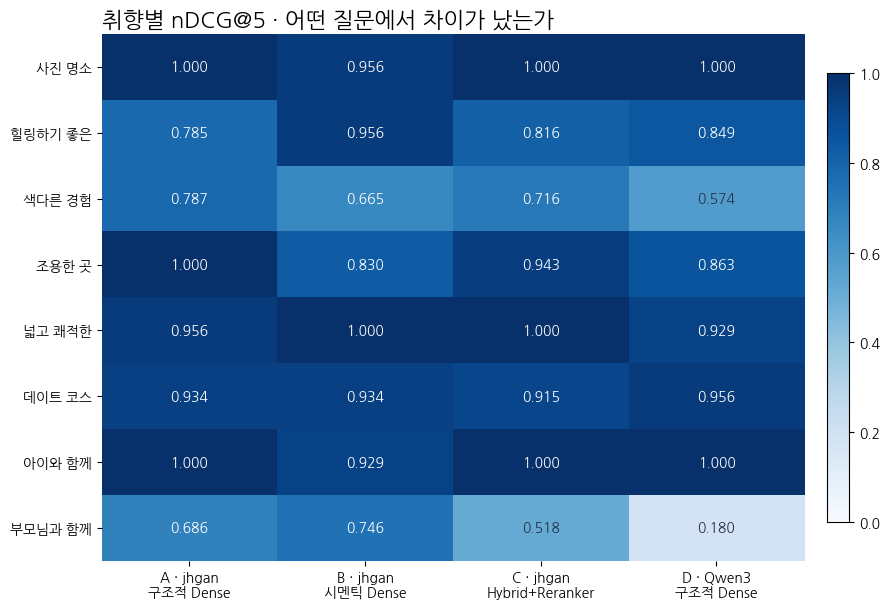

In [ ]:
preference_matrix = (
    metrics_by_query.groupby(["preference_label", "combo_id"]).ndcg_at_5.mean()
    .unstack().reindex(index=preference_order, columns=order)
)

fig, ax = plt.subplots(figsize=(9, 6.2))
image = ax.imshow(preference_matrix.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(4), [short_labels[c] for c in order])
ax.set_yticks(range(len(preference_matrix)), preference_matrix.index)
for i in range(preference_matrix.shape[0]):
    for j in range(preference_matrix.shape[1]):
        value = preference_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center",
                color="white" if value > .58 else "#263247", fontweight="bold")
ax.set_title("취향별 nDCG@5 · 어떤 질문에서 차이가 났는가", loc="left", fontsize=16, fontweight="bold")
ax.spines[:].set_visible(False)
plt.colorbar(image, ax=ax, fraction=.03, pad=.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "preference_ndcg_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. 취향별 Top 5 결과 카드

이제 평균 점수 뒤에 숨은 실제 결과를 봅니다. 아래에는 취향별 셀을 따로 만들어 두었으므로 변수를 수정할 필요가 없습니다.

- 초록 `2점`: 강한 정답
- 노랑 `1점`: 보조 정답
- 회색 `0점`: 무관 또는 근거 부족

유사도 숫자는 모델 간 절대 비교하지 않습니다. **장소 순위·정답 등급·근거 청크의 내용**을 중심으로 비교하세요. 카드에 들어간 청크는 해당 장소의 최고 점수 근거이며 120토큰 전문을 생략하지 않습니다.

In [ ]:
def show_preference_results(preference_code, query_variant=1):
    case = queries[
        queries.preference_code.eq(preference_code)
        & queries.query_variant.eq(query_variant)
    ].iloc[0]
    truth = truth_by_preference[preference_code]
    counts = pd.Series(list(truth.values())).value_counts().reindex([2,1,0], fill_value=0)
    cards = []
    for combo in COMBOS:
        frame = rankings[
            rankings.combo_id.eq(combo["id"]) & rankings.case_id.eq(case.case_id)
        ].sort_values("rank")
        items = []
        for row in frame.itertuples():
            grade = int(truth.get(str(row.content_id), 0))
            badge_class = f"grade-{grade}"
            badge_text = {2:"2점 · 강한 정답", 1:"1점 · 보조 정답", 0:"0점 · 무관"}[grade]
            items.append(f'''<article class="result-item">
              <div class="result-title"><span class="rank">{int(row.rank)}</span>{html.escape(str(row.place_title))}
                <span class="badge {badge_class}">{badge_text}</span></div>
              <div class="source">{html.escape(str(row.source_type))}</div>
              <div class="evidence">{html.escape(str(row.chunk_body))}</div>
            </article>''')
        cards.append(f'''<section class="combo-card" style="border-top:6px solid {combo['color']}">
          <h3>{combo['id']} · {html.escape(combo['label'])}</h3>{''.join(items)}
        </section>''')

    display(HTML(f'''<style>
      .result-report{{font-family:Arial,sans-serif;color:#263247;margin:24px 0}}
      .result-summary{{background:#F4F7FA;border-radius:10px;padding:11px 14px;margin:10px 0 16px}}
      .combo-grid{{display:grid;grid-template-columns:repeat(2,minmax(0,1fr));gap:16px;align-items:start}}
      .combo-card{{border-radius:12px;background:#fff;padding:14px;box-shadow:0 2px 10px #24334A18}}
      .combo-card h3{{margin:0 0 10px;font-size:15px}}
      .result-item{{border-top:1px solid #E7EBF0;padding:10px 0}}
      .result-item:first-of-type{{border-top:0}}
      .result-title{{font-weight:700;font-size:14px;line-height:1.5}}
      .rank{{display:inline-block;width:24px;height:24px;line-height:24px;text-align:center;border-radius:50%;background:#263247;color:white;margin-right:7px}}
      .badge{{display:inline-block;border-radius:12px;padding:2px 7px;margin-left:5px;font-size:10px}}
      .grade-2{{background:#DDF1E5;color:#236B43}} .grade-1{{background:#FFF0C9;color:#845D08}} .grade-0{{background:#E9EDF2;color:#667085}}
      .source{{font-size:11px;color:#68778D;margin:4px 0}}
      .evidence{{font-size:12px;line-height:1.65;white-space:pre-wrap;overflow-wrap:anywhere}}
      @media(max-width:950px){{.combo-grid{{grid-template-columns:1fr}}}}
    </style><section class="result-report">
      <h2>{html.escape(str(case.preference_label))}</h2>
      <div><b>평가 질의:</b> {html.escape(str(case['query']))}</div>
      <div class="result-summary"><b>55곳 정답 분포:</b> 2점 {int(counts[2])}곳 · 1점 {int(counts[1])}곳 · 0점 {int(counts[0])}곳</div>
      <div class="combo-grid">{''.join(cards)}</div>
    </section>'''))

### 12-1. 사진 명소

In [ ]:
show_preference_results('photo_spot')

In [ ]:
show_preference_results('photo_spot')

### 12-2. 힐링하기 좋은

In [ ]:
show_preference_results('healing')

### 12-3. 색다른 경험

In [ ]:
show_preference_results('unique')

### 12-4. 조용한 곳

In [ ]:
show_preference_results('quiet')

### 12-5. 넓고 쾌적한

In [ ]:
show_preference_results('spacious')

### 12-6. 데이트 코스

In [ ]:
show_preference_results('date')

### 12-7. 아이와 함께

In [ ]:
show_preference_results('with_kids')

### 12-8. 부모님과 함께

In [ ]:
show_preference_results('with_parents')

## 13. 결과 저장과 다운로드

평가 결과와 발표용 PNG를 ZIP 하나로 묶습니다. 임베딩 벡터 자체는 저장하지 않아 다운로드 용량을 줄였습니다.

ZIP에 포함되는 주요 파일:

- `metrics_summary.csv`: 네 조합 평균 평가 결과
- `metrics_by_query.csv`: 16개 질의별 평가 결과
- `rankings_top5.csv`: 질의별 Top 5와 근거 청크
- `build_timing.csv`, `search_timing.csv`: 시간 측정 원본
- `chunk_stats.csv`: 청킹 통계
- 발표용 PNG 4개

마지막 셀이 브라우저 다운로드를 시작합니다. Colab 런타임을 닫기 전에 다운로드가 끝났는지 확인하세요.

In [ ]:
metrics_summary.to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False, encoding="utf-8-sig")
metrics_by_query.to_csv(OUTPUT_DIR / "metrics_by_query.csv", index=False, encoding="utf-8-sig")
rankings.to_csv(OUTPUT_DIR / "rankings_top5.csv", index=False, encoding="utf-8-sig")
build_timing.to_csv(OUTPUT_DIR / "build_timing.csv", index=False, encoding="utf-8-sig")
search_timing.to_csv(OUTPUT_DIR / "search_timing.csv", index=False, encoding="utf-8-sig")
chunk_stats.to_csv(OUTPUT_DIR / "chunk_stats.csv", index=False, encoding="utf-8-sig")

summary = {
    "candidate_places": int(candidates.content_id.nunique()),
    "corpus_documents": int(len(docs)),
    "queries": int(len(queries)),
    "max_chunk_tokens": MAX_TOKENS,
    "semantic_threshold": SEMANTIC_THRESHOLD,
    "models": [JHGAN_MODEL, QWEN_MODEL],
    "reranker": RERANKER_MODEL,
    "model_load_seconds": {
        "jhgan": round(jhgan_load_seconds, 2),
        "qwen3": round(qwen_load_seconds, 2),
        "reranker": round(reranker_load_seconds, 2),
    },
    "build_time_definition": "chunking + corpus embedding (+ BM25 for combo C), model download/load excluded",
    "search_time_definition": "query embedding + retrieval + place aggregation (+ reranking for combo C), model load excluded",
}
(OUTPUT_DIR / "experiment_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)

zip_path = shutil.make_archive("/content/tripbranch_preference_eval_v1", "zip", OUTPUT_DIR)
print("저장 완료:", zip_path)
display(metrics_summary)

저장 완료: /content/tripbranch_preference_eval_v1.zip


,combo_id,precision_at_5,strict_precision_at_5,ndcg_at_5,조합,build_seconds,search_ms_per_query
0,A,0.9500,0.8375,0.893484,jhgan · 구조적 · Dense,50.062311,62.610521
1,B,0.9250,0.8375,0.877160,jhgan · 시멘틱 · Dense,75.792923,59.203888
2,C,0.9500,0.8125,0.863589,jhgan · 구조적 · Hybrid+Reranker,67.723814,1209.812459
3,D,0.8875,0.7375,0.793931,Qwen3 · 구조적 · Dense,83.956803,97.511057


In [ ]:
from google.colab import files
files.download("/content/tripbranch_preference_eval_v1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>